# Assignment 3 — Reactive Transport  

In [22]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# ---------- Formatting rule ----------
def fmt_rule(x):
    """If |x| < 1 (and not zero), show scientific notation with 3 decimals; else 3 decimals."""
    if x is None or (isinstance(x, float) and (math.isnan(x))):
        return "NaN"
    x = float(x)
    if x == 0.0:
        return "0.000"
    if abs(x) < 1.0:
        return f"{x:.3e}"
    return f"{x:.3f}"


def make_table(rows, columns=("Quantity", "Value", "Units")):
    """rows: list of (quantity, value, units)."""
    out = []
    for q, v, u in rows:
        if isinstance(v, (int, float, np.floating, np.integer)):
            out.append((q, fmt_rule(v), u))
        else:
            out.append((q, v, u))
    return pd.DataFrame(out, columns=list(columns))


def show_table(df, title):
    print(title)
    print("-"*len(title))
    display(df)


---
# Question 1 (30 pts) — Carbonate speciation and calcite


## Q1 Part 1 — Carbonate speciation (given pH and CO₂)

Given:
- $[CO_2(aq)] = 2.0$ mmol/L  
- pH = 6.00  →  $[H^+] = 10^{-6}$ M  
- $K_1 = 10^{-1.47}$
- $K_2 = 10^{-6.35}$
- $K_3 = 10^{-10.33}$ (25°C)

Compute:
$$[H_2CO_3] = K_1[CO_2]$$
$$[HCO_3^-] = \frac{K_2[H_2CO_3]}{[H^+]}$$
$$[CO_3^{2-}] = \frac{K_3[HCO_3^-]}{[H^+]}$$


In [23]:

# Inputs 
CO2_mmol_L = 2.0
pH_fixed   = 6.00
K1 = 10**(-1.47)
K2 = 10**(-6.35)
K3 = 10**(-10.33) 
KSP_CALCITE = 10**(-8.48)
KW = 1e-14


def carbonate_speciation_from_CO2_pH(CO2_mmol_L, pH, K1=K1, K2=K2, K3=K3):
    CO2 = CO2_mmol_L / 1000.0  # mol/L
    H   = 10**(-pH)            # mol/L
    
    H2CO3 = K1 * CO2
    HCO3  = K2 * H2CO3 / H
    CO3   = K3 * HCO3 / H
    
    return {
        "H2CO3_mmol_L": H2CO3*1000.0,
        "HCO3_mmol_L" : HCO3*1000.0,
        "CO3_mmol_L"  : CO3*1000.0,
        "H_mol_L"     : H
    }


spec = carbonate_speciation_from_CO2_pH(CO2_mmol_L, pH_fixed)
total_carb = spec["H2CO3_mmol_L"] + spec["HCO3_mmol_L"] + spec["CO3_mmol_L"]

df_q1p1 = make_table([
    ("pH", pH_fixed, "(-)"),
    ("[CO2(aq)]", CO2_mmol_L, "mmol/L"),
    ("[H2CO3]", spec["H2CO3_mmol_L"], "mmol/L"),
    ("[HCO3-]",  spec["HCO3_mmol_L"], "mmol/L"),
    ("[CO3^2-]", spec["CO3_mmol_L"], "mmol/L"),
    ("Total carbonate (sum)", total_carb, "mmol/L"),
])

show_table(df_q1p1, "Q1 Part 1 — Carbonate species at fixed pH")


Q1 Part 1 — Carbonate species at fixed pH
-----------------------------------------


,Quantity,Value,Units
0,pH,6.000,(-)
1,[CO2(aq)],2.000,mmol/L
2,[H2CO3],6.777e-02,mmol/L
3,[HCO3-],3.027e-02,mmol/L
4,[CO3^2-],1.416e-06,mmol/L
5,Total carbonate (sum),9.804e-02,mmol/L


---
## Q1 Part 2 — Will calcite dissolve or precipitate

#### with initial $[Ca^{2+}] = 0$?

Calcite:
$$CaCO_3(s) \rightleftharpoons Ca^{2+} + CO_3^{2-}$$

Ion activity product (approx.):
$$IAP = [Ca^{2+}][CO_3^{2-}]$$

With initial $[Ca^{2+}]=0$, then $IAP=0$, so $IAP < K_{sp}$ ⇒ **undersaturated** ⇒ **calcite dissolves**.


In [24]:
def calcite_SI(Ca_mmol_L, CO3_mmol_L, Ksp=KSP_CALCITE):
    Ca  = Ca_mmol_L / 1000.0   # mol/L
    CO3 = CO3_mmol_L / 1000.0  # mol/L
    IAP = Ca * CO3
    if IAP <= 0:
        SI = -np.inf
    else:
        SI = math.log10(IAP / Ksp)
    return IAP, Ksp, SI


IAP0, Ksp0, SI0 = calcite_SI(0.0, spec["CO3_mmol_L"], KSP_CALCITE)
verdict = "UNDERSATURATED → calcite DISSOLVES" if SI0 < 0 else ("SUPERSATURATED → calcite PRECIPITATES" if SI0 > 0 else "AT EQUILIBRIUM")

df_q1p2 = make_table([
    ("IAP = [Ca2+][CO3^2-]", IAP0, "(-)"),
    ("Ksp(calcite)", Ksp0, "(-)"),
    ("SI = log10(IAP/Ksp)", SI0, "(-)"),
    ("Conclusion", verdict, ""),
])

show_table(df_q1p2, "Q1 Part 2 — Calcite saturation check (initial Ca2+ = 0)")


Q1 Part 2 — Calcite saturation check (initial Ca2+ = 0)
-------------------------------------------------------


,Quantity,Value,Units
0,IAP = [Ca2+][CO3^2-],0.000,(-)
1,Ksp(calcite),3.311e-09,(-)
2,SI = log10(IAP/Ksp),-inf,(-)
3,Conclusion,UNDERSATURATED → calcite DISSOLVES,


---
## Q1 Part 3 — Estimate equilibrium $[Ca^{2+}]$ after calcite dissolution

We estimate equilibrium assuming:
- **CO₂(aq) stays fixed** at the given value (2.0 mmol/L)
- activity coefficients ≈ 1 (dilute)
- Use charge balance + calcite equilibrium

Solve for pH such that:
$$2[Ca^{2+}]+[H^+]=[HCO_3^-]+2[CO_3^{2-}]+[OH^-]$$
with $[OH^-]=K_w/[H^+]$

and $[Ca^{2+}]=K_{sp}/[CO_3^{2-}]$.


In [25]:
def carbonate_molar_species(H, CO2_mmol_L, K1=K1, K2=K2, K3=K3):
    CO2 = CO2_mmol_L/1000.0
    H2CO3 = K1 * CO2
    HCO3  = K2 * H2CO3 / H
    CO3   = K3 * HCO3 / H
    return H2CO3, HCO3, CO3


def charge_balance_residual_logH(logH, CO2_mmol_L, Ksp=KSP_CALCITE, Kw=KW):
    H = 10**logH
    OH = Kw / H
    H2CO3, HCO3, CO3 = carbonate_molar_species(H, CO2_mmol_L)
    Ca = Ksp / CO3
    return (2*Ca + H) - (HCO3 + 2*CO3 + OH)


def bisect(f, a, b, tol=1e-12, maxiter=200):
    fa, fb = f(a), f(b)
    if fa*fb > 0:
        raise ValueError("No sign change in bracket.")
    for _ in range(maxiter):
        m = 0.5*(a+b)
        fm = f(m)
        if abs(fm) < tol or abs(b-a) < tol:
            return m
        if fa*fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5*(a+b)

# Bracket root over pH range
pH_scan = np.linspace(4.0, 11.0, 2001)
logH_scan = -pH_scan
res = np.array([charge_balance_residual_logH(lh, CO2_mmol_L) for lh in logH_scan])
idx = np.where(np.sign(res[:-1]) * np.sign(res[1:]) < 0)[0]
if len(idx) == 0:
    raise RuntimeError("Could not bracket solution; widen pH_scan.")

a, b = logH_scan[idx[0]], logH_scan[idx[0]+1]
logH_star = bisect(lambda lh: charge_balance_residual_logH(lh, CO2_mmol_L), a, b)

H_star = 10**logH_star
pH_star = -logH_star
H2CO3, HCO3, CO3 = carbonate_molar_species(H_star, CO2_mmol_L)
Ca = KSP_CALCITE / CO3

df_q1p3 = make_table([
    ("pH*", pH_star, "(-)"),
    ("[Ca2+]*", Ca*1000.0, "mmol/L"),
    ("[H2CO3]*", H2CO3*1000.0, "mmol/L"),
    ("[HCO3-]*", HCO3*1000.0, "mmol/L"),
    ("[CO3^2-]*", CO3*1000.0, "mmol/L"),
])

show_table(df_q1p3, "Q1 Part 3 — Equilibrium estimate with calcite (CO2 fixed)")


Q1 Part 3 — Equilibrium estimate with calcite (CO2 fixed)
---------------------------------------------------------


,Quantity,Value,Units
0,pH*,7.729,(-)
1,[Ca2+]*,8.151e-01,mmol/L
2,[H2CO3]*,6.777e-02,mmol/L
3,[HCO3-]*,1.622,mmol/L
4,[CO3^2-]*,4.063e-03,mmol/L


---
---
# Question 2 (70 pts)
#### 1‑D steady-state transport at Bemidji


## Q2 Part 1 — Conservative chloride (calculation)

Given:
- $v=0.3$ m/day, $\alpha_L=1.0$ m  
- $C_0(Cl^-)=20$ mg/L

Compute:
$$D = \alpha_L v$$

Steady-state conservative transport gives:
$$C(x)=C_0$$
(so it does **not** change with distance for this boundary-value problem).


---
## Q2 Part 1a — Calculate Dispersion coefficient

In [26]:
# Inputs for Q2 (EDIT if needed)
v       = 0.3
alpha_L = 1.0
k       = 0.005

C0_Cl = 20.0
C0_Fe = 1.8

x_points = np.array([0, 25, 75, 150], dtype=float)

D = alpha_L * v

df_q2p1 = make_table([
    ("v", v, "m/day"),
    ("α_L", alpha_L, "m"),
    ("D = α_L * v", D, "m^2/day"),
    ("C0(Cl-)", C0_Cl, "mg/L"),
])

show_table(df_q2p1, "Q2 Part 1a — Calculate Dispersion coefficient")


Q2 Part 1a — Calculate Dispersion coefficient
---------------------------------------------


,Quantity,Value,Units
0,v,3.000e-01,m/day
1,α_L,1.000,m
2,D = α_L * v,3.000e-01,m^2/day
3,C0(Cl-),20.000,mg/L


---
## Q2 Part 1b — Derive the steady-state concentration profile:
#### $C(x)$ for conservative $Cl^-$

#### Governing steady-state conservative ADE:
$$
D\frac{d^{2}C}{dx^{2}}-v\frac{dC}{dx}=0
$$

#### Let $m=\frac{dC}{dx}$, so $\frac{d^{2}C}{dx^{2}}=\frac{dm}{dx}$:
$$
D\frac{dm}{dx}-vm=0
$$

##### Separate variables and integrate:
$$
\frac{1}{m}\,dm=\frac{v}{D}\,dx
$$
$$
\ln(m)=\frac{v}{D}x+\ln(m_0)
$$
$$
m=m_0 e^{(v/D)x}
$$

##### Since $m=\frac{dC}{dx}$, integrate from $x=0$ to $x$ and apply $C(0)=C_0$:
$$
C(x)-C_0=\int_{0}^{x} m_0 e^{(v/D)/x}\,dx
$$

#### Evaluate the integral:
$$
C(x)-C_0
= m_0\left[\frac{D}{v}e^{(v/D)/x}\right]_{0}^{x}
= \frac{D}{v}m_0\left(e^{(v/D)x}-1\right)
$$

#### So the general solution is:
$$
C(x)=C_0+\frac{D}{v}m_0\left(e^{(v/D)x}-1\right)
$$

#### Boundedness as $x\to\infty$ requires $m_0=0$ (since $e^{(v/D)x}\to\infty$ for $v>0$, $D>0$):
$$
m_0=0
$$

##### Final steady-state profile:
$$
\boxed{C(x)=C_0}
$$

---
## Q2 Part 1c — Compute Chloride concentrations

In [27]:
df_q2p1c = make_table([(f"C_Cl(x={int(x)} m)", C0_Cl, "mg/L") for x in x_points])
show_table(df_q2p1c, "Q2 Part 1c — Compute Chloride concentrations (conservative)")

Q2 Part 1c — Compute Chloride concentrations (conservative)
-----------------------------------------------------------


,Quantity,Value,Units
0,C_Cl(x=0 m),20.000,mg/L
1,C_Cl(x=25 m),20.000,mg/L
2,C_Cl(x=75 m),20.000,mg/L
3,C_Cl(x=150 m),20.000,mg/L


---
## Q2 Part 2 — Reactive Fe²⁺ (first-order removal)

Governing steady-state equation:
$$D\frac{d^2C}{dx^2}-v\frac{dC}{dx}-kC=0$$

Bounded solution:
$$C(x)=C_0e^{-\lambda x}$$
where
$$\lambda = \frac{\sqrt{v^2+4kD}-v}{2D},\quad L=\frac{1}{\lambda}$$


---
#### Q2 Part 2a — Fe2+ attenuation parameters

In [28]:
lam = (np.sqrt(v**2 + 4*k*D) - v) / (2*D)
lam = abs(lam)
L = 1/lam

df_q2p2a = make_table([
    ("k", k, "1/day"),
    ("λ", lam, "1/m"),
    ("L = 1/λ", L, "m"),
    ("C0(Fe2+)", C0_Fe, "mg/L"),
])
show_table(df_q2p2a, "Q2 Part 2a — Fe2+ attenuation parameters")



Q2 Part 2a — Fe2+ attenuation parameters
----------------------------------------


,Quantity,Value,Units
0,k,5.000e-03,1/day
1,λ,1.640e-02,1/m
2,L = 1/λ,60.984,m
3,C0(Fe2+),1.800,mg/L


---
#### Q2 Part 2b — Fe2+ concentrations (reactive)


In [29]:
df_q2p2b = make_table([(f"C_Fe(x={int(x)} m)", C0_Fe*np.exp(-lam*x), "mg/L") for x in x_points])
show_table(df_q2p2b, "Q2 Part 2b — Fe2+ concentrations (reactive)")

Q2 Part 2b — Fe2+ concentrations (reactive)
-------------------------------------------


,Quantity,Value,Units
0,C_Fe(x=0 m),1.800,mg/L
1,C_Fe(x=25 m),1.195,mg/L
2,C_Fe(x=75 m),5.262e-01,mg/L
3,C_Fe(x=150 m),1.538e-01,mg/L


---
## Q2 Part 3 — Plot + interpretation

**(a) Plot:** See the plot produced in the code cell below.

**(b) Which is conservative vs reaction-limited?**  
- **Cl⁻ is conservative** (no sink term), so the steady-state solution stays at **$C(x)=C_0$**.  
- **Fe²⁺ is reaction-limited** because it includes a **first-order removal term** $kC$, producing exponential decay with distance.

**(c) What do $\lambda$ and $L$ mean?**  
- $\lambda$ (1/m) is a **spatial attenuation rate**: larger $\lambda$ means faster decay per meter.  
- $L=1/\lambda$ (m) is a **characteristic plume length**: at $x=L$, $C \approx C_0/e$ (~37% of $C_0$).


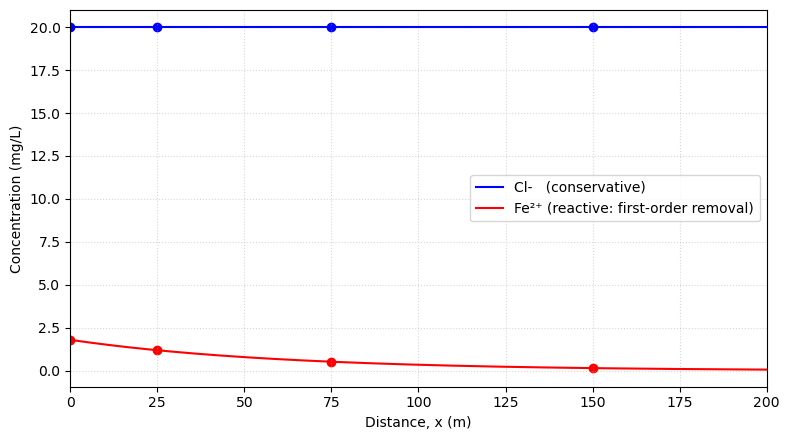

In [47]:
# Plot for Q2 Part 3
x_profile = np.linspace(0, 200, 500)
Cl_prof = C0_Cl * np.ones_like(x_profile)
Fe_prof = C0_Fe * np.exp(-lam*x_profile)

plt.figure(figsize=(8,4.5))
plt.plot(x_profile, Cl_prof, "b-", label="Cl-   (conservative)")
plt.plot(x_profile, Fe_prof, "r-", label="Fe²⁺ (reactive: first-order removal)")
plt.scatter(x_points, C0_Cl*np.ones_like(x_points), c="blue")
plt.scatter(x_points, C0_Fe*np.exp(-lam*x_points), c="red")
plt.xlabel("Distance, x (m)")
plt.ylabel("Concentration (mg/L)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.xlim(0, x_profile.max())
plt.legend()
plt.tight_layout()
plt.show()


---
## Q2 Part 4 — Ng et al. (2015) paper questions

**(a) Which redox reaction produces Fe²⁺?**  
Fe²⁺ is produced by **microbial reduction of Fe(III) minerals** (iron-reducing conditions), converting Fe(III) → Fe(II) during anaerobic biodegradation.

**(b) Why doesn’t Fe²⁺ accumulate indefinitely?**  
Because dissolved Fe²⁺ is removed by processes such as **sorption to sediments** and **secondary mineral precipitation** (e.g., ferrous carbonates/sulfides), which limit dissolved concentrations.

**(c) How does CH₄ indicate terminal redox conditions?**  
CH₄ indicates **methanogenesis**, which typically occurs after more energetically favorable electron acceptors (O₂, NO₃⁻, Mn(IV), Fe(III), SO₄²⁻) have been depleted—so it reflects **strongly reducing, late-stage redox conditions**.

**(d) Give two processes that reduce secondary plume concentrations.**  
Two valid processes are:
1. **Sorption/retardation** onto aquifer solids (especially for Fe).  
2. **Mineral precipitation** (removing dissolved species into solids).  
(Depending on the compound, **outgassing** can also reduce dissolved concentrations for volatile species like CH₄/CO₂.)


---
## Q2 Part 5 — Retardation (R = 2.5)

The assignment’s Eq. 4 includes retardation:
$$R\frac{\partial C}{\partial t} = D\frac{\partial^2 C}{\partial x^2} - v\frac{\partial C}{\partial x} - kC$$

At **steady state**, $\partial C/\partial t = 0$, so the left-hand side is **zero**, and Eq. 4 reduces to:
$$D\frac{d^2 C}{dx^2} - v\frac{dC}{dx} - kC = 0$$

✅ **Conclusion:** For this problem’s *steady-state* concentration profiles, **retardation does not change $C(x)$**, and the computed $\lambda$ and $L$ remain the same.  

Retardation mainly affects **transient timing** (how fast the plume evolves in time), not the steady-state spatial shape.


In [33]:
pd.set_option("display.max_colwidth", None)
df_q2p5 = make_table([
    ("R", 2.5, "(-)"),
    ("Steady-state effect", "No change to C(x), λ, or L\n(R cancels when ∂C/∂t = 0)", ""),
])
show_table(df_q2p5, "Q2 Part 5 — Retardation summary")


Q2 Part 5 — Retardation summary
-------------------------------


,Quantity,Value,Units
0,R,2.500,(-)
1,Steady-state effect,"No change to C(x), λ, or L\n(R cancels when ∂C/∂t = 0)",


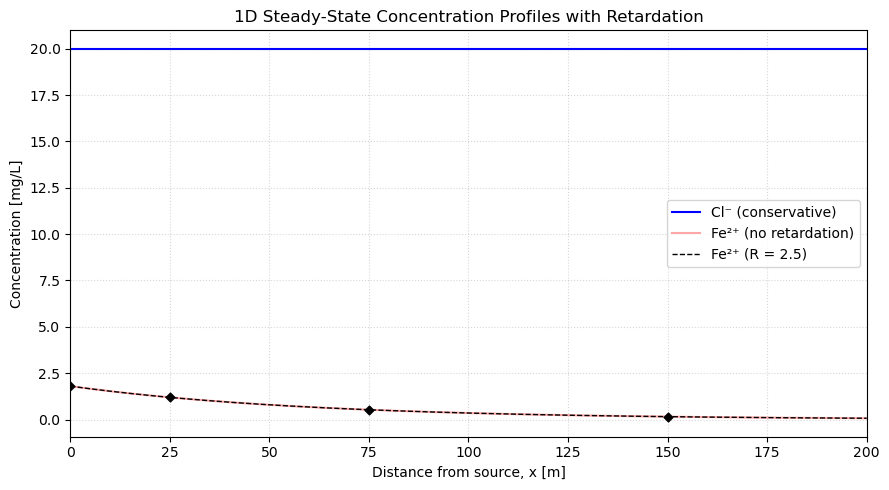

In [49]:
R = 2.5

def C_Fe(x, C0, lam):
    """ Steady-state Fe2+ concentration profile [mg/L] using Eq. 3: C(x) = C0 * exp(-lambda * x) """
    return C0 * np.exp(-lam * x)

fig, ax = plt.subplots(figsize=(9, 5))

# Conservative Cl-
ax.plot(x_profile, Cl_prof,
        color='blue', linewidth=1.5,
        label='Cl⁻ (conservative)')

# Fe²⁺ without retardation
ax.plot(x_profile, Fe_prof,
        color='red', linewidth=1.5, alpha=0.35,
        label='Fe²⁺ (no retardation)')

# ── Retardation calculation ─────────────────────────────
v_eff = v / R
k_eff = k / R
D_eff = alpha_L * v_eff

lambda_R = (v_eff / (2*D_eff)) * (1 - np.sqrt(1 + (4*k_eff*D_eff) / v_eff**2))
lambda_R = abs(lambda_R)
L_scale_R = 1 / lambda_R

Fe_profile_R = C_Fe(x_profile, C0_Fe, lambda_R)

# Fe²⁺ with retardation (dashed, on top)
ax.plot(x_profile, Fe_profile_R,
        color='black', linestyle='--',
        linewidth=1.0, zorder=10,
        label=f'Fe²⁺ (R = {R})')

ax.scatter(x_points,
           [C_Fe(x, C0_Fe, lambda_R) for x in x_points],
           color='black', s=20, zorder=15, marker='D')

ax.set_xlabel('Distance from source, x [m]')
ax.set_ylabel('Concentration [mg/L]')
ax.set_title('1D Steady-State Concentration Profiles with Retardation')
ax.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.xlim(0, x_profile.max())
plt.tight_layout()
plt.show()